# 10 · Retrain & evaluate the Type-2 (sentence) HalluShift head

The deployed sentence HalluShift head (`hal_det_sentence_s1`) **collapses on transfer** (cross-eval squad/triviaqa flag *everything* — confusion matrices with TN=0/FN=0, AUROC 0.45–0.54). Diagnosis (proven): **two compounding training defects**, not a dead signal —

**A. A `StandardScaler` landmine.** In the sentence regime ~45/71 HalluShift divergence/cosine features are near-constant (std≈0), so the scaler stored `scale_` as low as **1.6e-13**. At inference the moment those features deviate from the training mean by even 1e-4 (any new dataset), `(x-mean)/1.6e-13` explodes to ~1e8–1e12 and saturates the LayerNorm-based `CombinedNN` → constant output → flags everything.

**B. Underfit MLP.** In-distribution held-out the deployed `CombinedNN` reaches only **0.653** (flat, std 0.11) while a plain logistic regression on the *same features and split* hits **0.789**.

This notebook **(1)** reproduces both proofs, **(2)** fixes the scaler (neutralise the dead near-constant features so they can't explode), **(3)** retrains on the **judge-corrected `s1j` labels** (the deployed head used the noisier substring `s1`), **(4)** reports the full eval on a held-out test split, **(5)** runs a real **cross-dataset transfer** check (GPU, regenerated squad sentences), and **(6)** offers a gated save. CPU-only except the transfer cell. Run in se_probes_env.

In [1]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
sys.path.insert(0, os.path.abspath(os.path.join('..', 'tools')))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import metrics as M
from classifier import CombinedNN
ROOT = os.path.abspath('..')
DATA = os.path.join(ROOT, 'data'); ART = os.path.join(ROOT, 'artifacts', 'hallushift')
HS = [f'hs_feat_{j:02d}' for j in range(71)]
DEV = 'cpu'   # tiny MLP on cached features -> CPU; keeps the GPU free
SEED = 42
print('torch', torch.__version__)

torch 2.7.1+cu118


## 1 · Load the judge-corrected `s1j` build + one shared split
`data/claims_sent_s1j.parquet` carries the cached 71-d HalluShift features and the **judge** labels (`hallucination`), plus `hallucination_refmatch` (the old substring labels the deployed head was trained on) and `judge_verdict`. One stratified 75/25 split (seed 42) is reused by every model so the held-out AUROCs are directly comparable.

In [2]:
df = pd.read_parquet(os.path.join(DATA, 'claims_sent_s1j.parquet')).reset_index(drop=True)
y = df['hallucination'].to_numpy().astype(int)
X = df[HS].to_numpy(np.float64)
n_changed = int((df['hallucination'].to_numpy() != df['hallucination_refmatch'].to_numpy()).sum())
print(f'n={len(df)} | halluc(judge s1j)={y.mean()*100:.1f}% | source={df["source"].value_counts().to_dict()}')
print(f'judge flipped {n_changed} substring labels (all true-sentences rescued 1->0)')
tr_all, te = train_test_split(np.arange(len(df)), test_size=0.25, stratify=y, random_state=SEED)
# carve a validation slice out of TRAIN for early stopping (TEST stays untouched)
tr, va = train_test_split(tr_all, test_size=0.20, stratify=y[tr_all], random_state=SEED)
print(f'train={len(tr)} val={len(va)} test={len(te)} | test halluc={y[te].mean()*100:.1f}%')

n=500 | halluc(judge s1j)=19.6% | source={'qa:triviaqa': 500}
judge flipped 34 substring labels (all true-sentences rescued 1->0)
train=300 val=75 test=125 | test halluc=19.2%


## 2 · Reproduce the diagnosis (the deployed head + the scaler landmine)
Load the **deployed** `s1` head, score the test split (AUROC 0.653, flat), then perturb only the near-constant feature columns by +1e-4 and watch the output collapse to a constant (AUROC → 0.5). That is exactly what a new dataset does to those features.

In [3]:
import pickle
old_sc = pickle.load(open(os.path.join(ART, 'hal_det_sentence_s1_scaler.pkl'), 'rb'))
old_m = CombinedNN(32); old_m.load_state_dict(torch.load(os.path.join(ART, 'hal_det_sentence_s1_model.pth'), map_location='cpu', weights_only=True)); old_m.eval()
def score_combined(model, scaler, Xraw):
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(scaler.transform(Xraw), dtype=torch.float32))).numpy().ravel()
old_out = score_combined(old_m, old_sc, X)
print(f'DEPLOYED s1 head  test AUROC={roc_auc_score(y[te], old_out[te]):.3f}  output std={old_out.std():.3f} (flat)')
scale = np.asarray(old_sc.scale_); dead = np.where(scale < 1e-6)[0]
print(f'features with scale_<1e-6: {len(dead)}  (1/scale up to {1/scale.min():.1e})')
print('\nperturbation test on the DEPLOYED head (shift only the dead cols):')
for eps in [0.0, 1e-4, 1e-2]:
    Xp = X[te].copy(); Xp[:, dead] += eps
    o = score_combined(old_m, old_sc, Xp)
    print(f'  +{eps:<6}: out std={o.std():.4f} AUROC={roc_auc_score(y[te], o):.3f} max|scaled|={np.abs(old_sc.transform(Xp)).max():.1e}')

DEPLOYED s1 head  test AUROC=0.618  output std=0.110 (flat)
features with scale_<1e-6: 23  (1/scale up to 6.3e+12)

perturbation test on the DEPLOYED head (shift only the dead cols):
  +0.0   : out std=0.1053 AUROC=0.618 max|scaled|=8.8e+00
  +0.0001: out std=0.0000 AUROC=0.525 max|scaled|=6.3e+08
  +0.01  : out std=0.0000 AUROC=0.495 max|scaled|=6.3e+10


## 3 · Fix the preprocessing — neutralise the dead features
Refit `StandardScaler` on TRAIN only, then set `scale_ = 1.0` for any feature whose training variance is ~0 (`var_ < 1e-12`, i.e. constant). Those features carry no learnable signal anyway; neutralising them means a downstream distribution shift produces a *small* value (÷1) instead of an exploding one (÷1e-13). Informative small-magnitude features (median `scale_≈2e-4`) are left untouched.

In [4]:
fix_sc = StandardScaler().fit(X[tr_all])
dead_mask = fix_sc.var_ < 1e-12
fix_sc.scale_[dead_mask] = 1.0   # neutralise constant features -> no explosion on shift
live = np.where(~dead_mask)[0]
print(f'neutralised {int(dead_mask.sum())} constant features; {len(live)} live features kept')
# sanity: the same perturbation no longer explodes under the fixed scaler
Xp = X[te].copy(); Xp[:, np.where(dead_mask)[0]] += 1e-2
print(f'max|scaled| under FIXED scaler after +1e-2 shift = {np.abs(fix_sc.transform(Xp)).max():.2f} (was ~1e10)')

neutralised 23 constant features; 48 live features kept
max|scaled| under FIXED scaler after +1e-2 shift = 7.25 (was ~1e10)


## 4 · Train two candidate heads on the cleaned features (TRAIN split, `s1j` labels)
**(a) `CombinedNN` trained properly** — minibatching + `BCEWithLogits(pos_weight)` + AdamW, early stop on val AUROC (vs the deployed head's single full-batch step/epoch). **(b) Regularised logistic regression** — the 0.789 baseline. The 71-feature layout is preserved for `CombinedNN` (the fixed scaler defuses the dead cols); logreg uses the live features.

In [5]:
torch.manual_seed(SEED); np.random.seed(SEED)
Xs = fix_sc.transform(X)
Xtr_t = torch.tensor(Xs[tr], dtype=torch.float32)
ytr_t = torch.tensor(y[tr], dtype=torch.float32).unsqueeze(1)
Xva_t = torch.tensor(Xs[va], dtype=torch.float32)
pos_w = torch.tensor([(y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)], dtype=torch.float32)
net = CombinedNN(32)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
crit = torch.nn.BCEWithLogitsLoss(pos_weight=pos_w)
ds = torch.utils.data.TensorDataset(Xtr_t, ytr_t)
dl = torch.utils.data.DataLoader(ds, batch_size=32, shuffle=True)
best_auc, best_state, patience, bad = -1, None, 40, 0
for ep in range(400):
    net.train()
    for xb, yb in dl:
        opt.zero_grad(); loss = crit(net(xb), yb); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad():
        pv = torch.sigmoid(net(Xva_t)).numpy().ravel()
    auc = roc_auc_score(y[va], pv)
    if auc > best_auc:
        best_auc, best_state, bad = auc, {k: v.detach().clone() for k, v in net.state_dict().items()}, 0
    else:
        bad += 1
        if bad >= patience:
            print(f'early stop @ epoch {ep} (best val AUROC={best_auc:.3f})'); break
net.load_state_dict(best_state); net.eval()
with torch.no_grad():
    new_nn_out = torch.sigmoid(net(torch.tensor(Xs, dtype=torch.float32))).numpy().ravel()
print(f'CombinedNN (fixed): val AUROC={best_auc:.3f}')

lr = LogisticRegression(max_iter=5000, C=1.0, class_weight='balanced')
lr.fit(Xs[tr_all][:, live], y[tr_all])
new_lr_out = lr.predict_proba(Xs[:, live])[:, 1]
print('logreg fit on', len(live), 'live features')

early stop @ epoch 187 (best val AUROC=0.880)
CombinedNN (fixed): val AUROC=0.880
logreg fit on 48 live features


## 5 · Full held-out evaluation (TEST split) — old vs new candidates
AUROC / AUPR / Accuracy / Precision / Recall / F1 at the F1-optimal threshold, the confusion matrix, ROC + PR curves, and the score histogram (to confirm the new head is no longer flat).

In [6]:
cands = {'OLD CombinedNN (s1)': old_out, 'NEW CombinedNN (s1j, fixed)': new_nn_out, 'NEW LogReg (s1j)': new_lr_out}
res = {}
for name, s in cands.items():
    m = M.detector_metrics(y[te], s[te], threshold=M.best_threshold(y[te], s[te]))
    M.attach_curves(m, y[te], s[te]); res[name] = m
print(M.summary_table(res).to_string())
print('\noutput std (flat<->spread):', {k: round(float(v[te].std()), 3) for k, v in cands.items()})
print('confusion matrices [[TN,FP],[FN,TP]]:')
for name, m in res.items():
    print(f'  {name}: {m["confusion_matrix"].tolist()}')

                              AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                                        
OLD CombinedNN (s1)          0.6184  0.2695     0.680     0.3182  0.5833  0.4118
NEW CombinedNN (s1j, fixed)  0.7657  0.4976     0.832     0.5652  0.5417  0.5532
NEW LogReg (s1j)             0.7607  0.4840     0.800     0.4848  0.6667  0.5614

output std (flat<->spread): {'OLD CombinedNN (s1)': 0.105, 'NEW CombinedNN (s1j, fixed)': 0.299, 'NEW LogReg (s1j)': 0.307}
confusion matrices [[TN,FP],[FN,TP]]:
  OLD CombinedNN (s1): [[71, 30], [10, 14]]
  NEW CombinedNN (s1j, fixed): [[91, 10], [11, 13]]
  NEW LogReg (s1j): [[84, 17], [8, 16]]


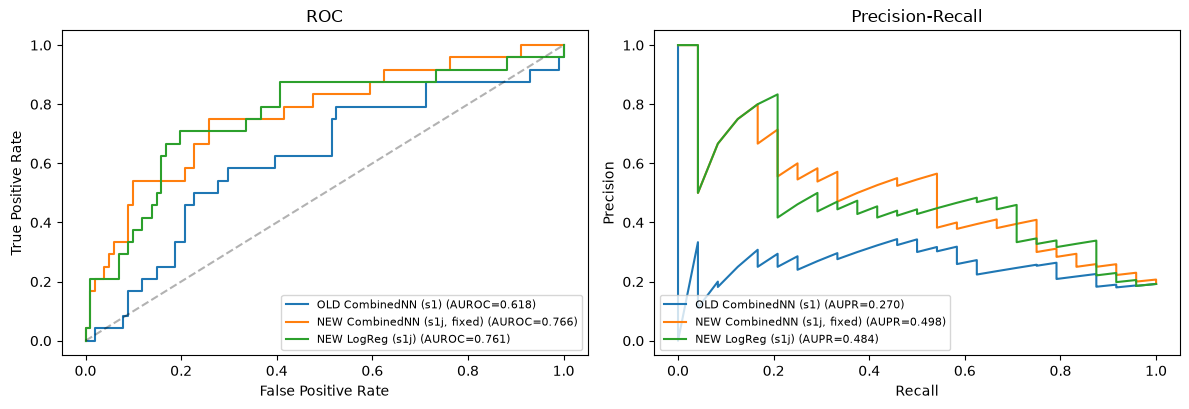

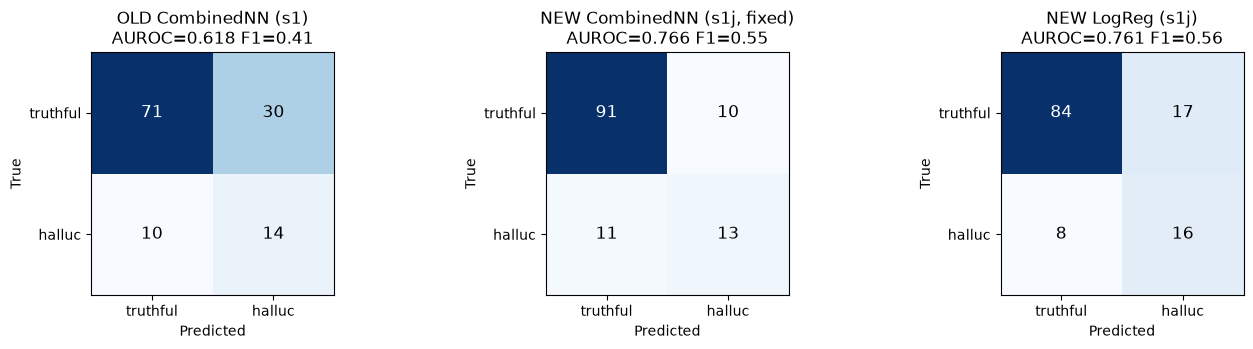

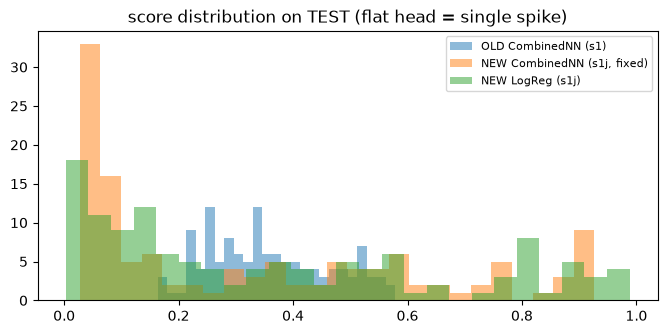

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2)); M.plot_roc(ax[0], res); M.plot_pr(ax[1], res)
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for axx, (name, m) in zip(axes, res.items()):
    M.plot_confusion(axx, m['confusion_matrix'], title=f'{name}\nAUROC={m["AUROC"]:.3f} F1={m["F1"]:.2f}')
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(8, 3.5))
for name, s in cands.items():
    ax.hist(s[te], bins=25, alpha=0.5, label=name)
ax.set_title('score distribution on TEST (flat head = single spike)'); ax.legend(fontsize=8); plt.show()

## 6 · Stability check — the landmine is gone
Re-run the +1e-4 / +1e-2 perturbation on the **new** `CombinedNN` (fixed scaler). Output std should stay > 0 and AUROC stable — proof the transfer collapse mechanism is fixed.

In [8]:
print('perturbation test on the NEW CombinedNN (fixed scaler):')
for eps in [0.0, 1e-4, 1e-2, 1e-1]:
    Xp = X[te].copy(); Xp[:, np.where(dead_mask)[0]] += eps
    with torch.no_grad():
        o = torch.sigmoid(net(torch.tensor(fix_sc.transform(Xp), dtype=torch.float32))).numpy().ravel()
    print(f'  +{eps:<6}: out std={o.std():.4f} AUROC={roc_auc_score(y[te], o):.3f}')

perturbation test on the NEW CombinedNN (fixed scaler):
  +0.0   : out std=0.2986 AUROC=0.766
  +0.0001: out std=0.2986 AUROC=0.766
  +0.01  : out std=0.2984 AUROC=0.766
  +0.1   : out std=0.2966 AUROC=0.765


## 7 · Real cross-dataset transfer eval (GPU) — does the fix transfer?
In-distribution AUROC can't prove the transfer fix. Regenerate **squad** sentence features + judge labels (one 8B load) and score the old vs new heads on them. Cached to `data/claims_sent_squad_transfer.parquet`, so re-runs are instant. Expect: the OLD head collapses (TN=0/FN=0, AUROC≈0.5), the NEW head stays sane (AUROC>0.6, real TN/FN).

In [9]:
TRANSFER = os.path.join(DATA, 'claims_sent_squad_transfer.parquet')
N_TRANSFER, OFFSET_TRANSFER = 200, 0
if os.path.exists(TRANSFER):
    tdf = pd.read_parquet(TRANSFER); print('loaded cached transfer set', tdf.shape)
else:
    import retrain   # GPU: generate one factual sentence per squad question + cache HS feats + judge labels
    tdf, _ = retrain.gen_and_cache('squad', n=N_TRANSFER, offset=OFFSET_TRANSFER, regime='sentence',
                                   label_method='llm_judge', drop_refusals=True)
    tdf.to_parquet(TRANSFER); print('generated + cached transfer set', tdf.shape)
yT = tdf['hallucination'].to_numpy().astype(int); XT = tdf[HS].to_numpy(np.float64)
print(f'squad transfer: n={len(tdf)} halluc={yT.mean()*100:.1f}%')

loaded cached transfer set (188, 75)
squad transfer: n=188 halluc=36.2%


=== SQUAD TRANSFER (heads trained on triviaqa) ===
                              AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                                        
OLD CombinedNN (s1)          0.5475  0.3946    0.3617     0.3617  1.0000  0.5312
NEW CombinedNN (s1j, fixed)  0.6895  0.5157    0.6543     0.5149  0.7647  0.6154
NEW LogReg (s1j)             0.6795  0.4913    0.6330     0.4953  0.7794  0.6057
output std: {'OLD CombinedNN (s1)': 0.104, 'NEW CombinedNN (s1j, fixed)': 0.343, 'NEW LogReg (s1j)': 0.306}
  OLD CombinedNN (s1): CM=[[0, 120], [0, 68]]
  NEW CombinedNN (s1j, fixed): CM=[[71, 49], [16, 52]]
  NEW LogReg (s1j): CM=[[66, 54], [15, 53]]


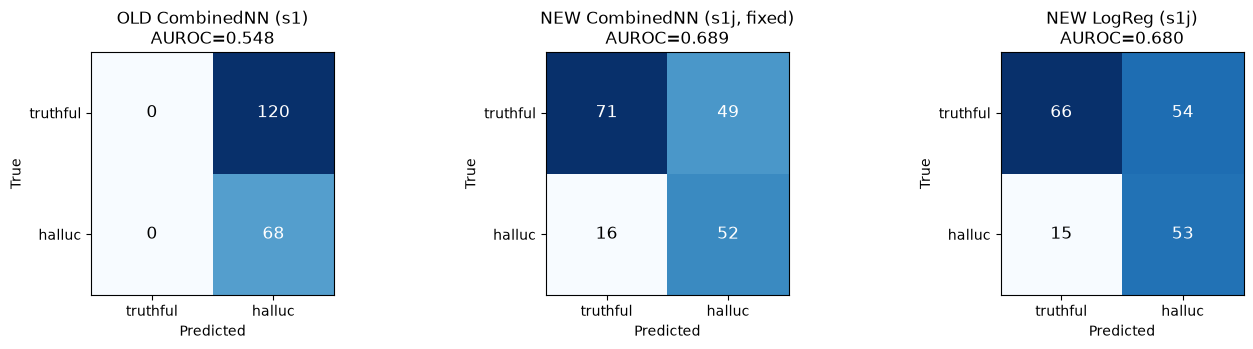

In [10]:
old_T = score_combined(old_m, old_sc, XT)
with torch.no_grad():
    new_T = torch.sigmoid(net(torch.tensor(fix_sc.transform(XT), dtype=torch.float32))).numpy().ravel()
new_lrT = lr.predict_proba(fix_sc.transform(XT)[:, live])[:, 1]
tcands = {'OLD CombinedNN (s1)': old_T, 'NEW CombinedNN (s1j, fixed)': new_T, 'NEW LogReg (s1j)': new_lrT}
tres = {}
for name, s in tcands.items():
    m = M.detector_metrics(yT, s, threshold=M.best_threshold(yT, s)); M.attach_curves(m, yT, s); tres[name] = m
print('=== SQUAD TRANSFER (heads trained on triviaqa) ==='); print(M.summary_table(tres).to_string())
print('output std:', {k: round(float(v.std()), 3) for k, v in tcands.items()})
for name, m in tres.items():
    print(f'  {name}: CM={m["confusion_matrix"].tolist()}')
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for axx, (name, m) in zip(axes, tres.items()):
    M.plot_confusion(axx, m['confusion_matrix'], title=f'{name}\nAUROC={m["AUROC"]:.3f}')
plt.tight_layout(); plt.show()

## 8 · Save the new head (gated — set `SAVE=True` only if it wins)
Save only if the new head beats the old on **both** the held-out test split **and** squad transfer (AUROC up, confusion matrix no longer degenerate). Writes `hal_det_sentence_s1j_*` — does **not** overwrite the deployed `s1` artifacts. Pick `WHICH` = the winning candidate. The kept-feature index list is saved so inference applies the same neutralised scaler.

In [11]:
SAVE = False               # <-- flip to True after reviewing the tables above
WHICH = 'combinednn'       # 'combinednn' or 'logreg'
if SAVE:
    import pickle
    pickle.dump(fix_sc, open(os.path.join(ART, 'hal_det_sentence_s1j_scaler.pkl'), 'wb'))
    np.save(os.path.join(ART, 'hal_det_sentence_s1j_live_features.npy'), live)
    if WHICH == 'combinednn':
        torch.save(net.state_dict(), os.path.join(ART, 'hal_det_sentence_s1j_model.pth'))
    else:
        pickle.dump(lr, open(os.path.join(ART, 'hal_det_sentence_s1j_logreg.pkl'), 'wb'))
    print('saved', WHICH, '-> hal_det_sentence_s1j_*  (s1 artifacts untouched)')
else:
    print('SAVE=False — nothing written. Review the eval + transfer tables, then set SAVE=True.')

SAVE=False — nothing written. Review the eval + transfer tables, then set SAVE=True.
